# Predicting Spotify Song Popularity

<div id="toc"></div>

## Exploring the Data

<b>Section Overview</b><br>
This section discusses shaping and visualizing the data. It comes from a relatively clean Kaggle dataset, so there weren't really any missing values to deal with. However, I did make a few changes involving dropping columns, sorting the data for easier analysis and changing some of the datatypes. There are a number of visualizations, primarily different scatterplots, to get a better understanding of the trends. 

<img src="Images/pairgrid.png" alt="feature pairgrid" width="350"/>

<b>Load in the data and packages</b><br>
The first step is to import the needed packages.

In [307]:
!pip install pandas
!pip install numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')

### Shaping the data
With the workstation set up, the next obvious step is to load and shape the data. To get the dataset into a format better suited for analysis, I chose to sort the observations  by their popularity scores and start the index from 1. This helps assess where songs rank compared to other songs. This is just for exploratory purposes, and the data will be re-shuffled later to try to avoid any unintented bias with the machine learning models.

In [309]:
spotify = pd.read_csv('Data/SpotifyFeatures0419.csv')

# Create the sorted dataframe, drop zeros, convert any categoricals
sort_data = spotify.sort_values('popularity', ascending=False).reset_index()
spotify_ordered = sort_data.drop(['index', 'track_id'], axis=1)
spotify_ordered.index = spotify_ordered.index + 1

spotify_ordered = spotify_ordered[spotify_ordered.popularity > 0]

spotify_ordered[['mode', 'key', 'time_signature']] = \
    spotify_ordered[['mode', 'key', 'time_signature']].astype('category')

A significant adjustment above is that all songs with a populartiy of zero were dropped, a reduction of 18,889 rows. This decision was made because of the low barrier of entry for songs to be hosted on Spotify, and the hope is that by removing these observations we can cut down on the noise in the dataset. Another change is the three columns that were changed to the type of category.<br>
<br>
For more insight into these and other decisions regarding data restructuring, refer to the data wrangling notebook in the Reports sub-folder of this repository, which can be found <a href='https://github.com/twillstw/Spotify-Popularity-Prediction/blob/master/Reports/1.%20Data%20Wrangling.ipynb'>here.</a>

In [311]:
spotify_ordered.shape

(111774, 16)

In [312]:
spotify_ordered.head()

,artist_name,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
1,Daddy Yankee,Con Calma,0.1100,0.737,193227,0.860,0.000002,8,0.0574,-2.652,0,0.0593,93.989,4,0.656,100
2,Post Malone,Wow.,0.1630,0.833,149520,0.539,0.000002,11,0.1010,-7.399,0,0.1780,99.947,4,0.385,98
3,Billie Eilish,bad guy,0.3080,0.708,194088,0.418,0.093000,0,0.1000,-10.998,1,0.3680,131.926,4,0.578,98
4,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,0.5200,0.744,158040,0.494,0.000000,2,0.0716,-5.563,1,0.0699,89.972,4,0.927,98
5,Jonas Brothers,Sucker,0.0427,0.842,181040,0.734,0.000000,1,0.1060,-5.065,0,0.0588,137.958,4,0.952,98


In [313]:
classified = spotify_ordered.copy()
classified['pop_rating'] = ''

for i, row in classified.iterrows():
    score = 'unpopular'
    if (row.popularity > 50) & (row.popularity < 75):
        score = 'medium'
    elif row.popularity >= 75:
        score = 'popular'
    classified.at[i, 'pop_rating'] = score

In [314]:
from datasets import load_dataset
import numpy as np
ds = load_dataset("akbargherbal/youtube-music-hits")

train_ds = ds["train"]
youtube_df = ds["train"].to_pandas()

In [315]:
# ==============================
# Integrating YouTube Engagement Data
# ==============================

from datasets import load_dataset
import pandas as pd
ds = load_dataset('akbargherbal/youtube-music-hits')
from datasets import load_dataset

ds = load_dataset('akbargherbal/youtube-music-hits')
train_ds = ds["train"]
youtube_df = ds["train"].to_pandas()
spotify_df = pd.read_csv("Data/SpotifyFeatures0419.csv")

spotify_df['track_lower'] = spotify_df['track_name'].str.lower().str.strip()
youtube_df['track_lower'] = youtube_df['itemLabel'].str.lower().str.strip()

spotify_df['artist_lower'] = spotify_df['artist_name'].str.lower().str.strip()
youtube_df['artist_lower'] = youtube_df['performerLabel'].str.lower().str.strip()

merged_df = pd.merge(
    spotify_df,
    youtube_df,
    left_on=['track_lower'],
    right_on=['track_lower'],
    how='left'
)

df_no_nan = merged_df.dropna(subset=['itemLabel'])
youtube_df = df_no_nan.copy()  

# Log-transform views to reduce skew
youtube_df['log_youtubeViews'] = np.log1p(youtube_df['youtubeViews'])

# Create lookup table (TRACK ONLY)
yt_features = youtube_df[['track_lower', 'log_youtubeViews']]

# Create matching key in classified
classified['track_lower'] = classified['track_name'].str.lower().str.strip()

# Merge YouTube engagement into classified
classified = classified.merge(
    yt_features,
    on='track_lower',
    how='left'
)

# Fill missing YouTube values (songs without YT presence)
classified['log_youtubeViews'] = classified['log_youtubeViews'].fillna(0)

# Cleanup
classified.drop(['track_lower'], axis=1, inplace=True)

In [316]:
# Inspect the new column
classified.head(3)

,artist_name,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,pop_rating,log_youtubeViews
0,Daddy Yankee,Con Calma,0.110,0.737,193227,0.860,0.000002,8,0.0574,-2.652,0,0.0593,93.989,4,0.656,100,popular,21.522119
1,Post Malone,Wow.,0.163,0.833,149520,0.539,0.000002,11,0.1010,-7.399,0,0.1780,99.947,4,0.385,98,popular,0.000000
2,Billie Eilish,bad guy,0.308,0.708,194088,0.418,0.093000,0,0.1000,-10.998,1,0.3680,131.926,4,0.578,98,popular,20.793433


### Visual EDA

Now that the data is loaded and shaped, it's important to get an understanding of the different variables, in particular the target variable. First, here's a plot to visualize the distribution of the target variable values.

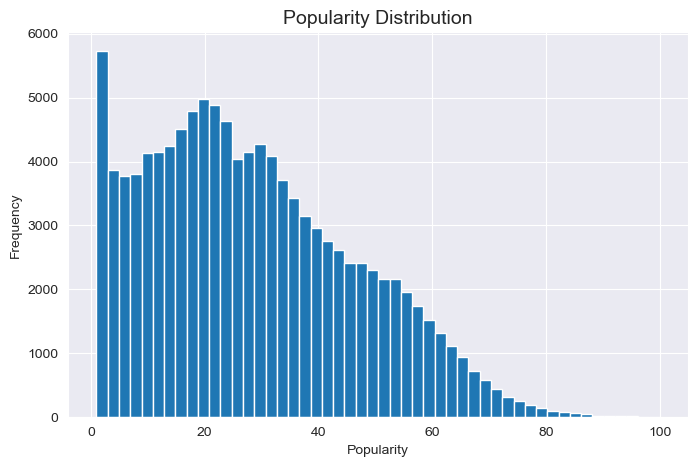

In [319]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
_ = spotify_ordered['popularity'].plot(kind='hist', bins=50)
_ = plt.xlabel('Popularity')
_ = plt.title('Popularity Distribution', fontsize=14)

<b>Correlations</b><br>
Having  examined the target variable, we can now examine the rest of the features and see how they correlate with each other, in particular how they correlate with the popularity column.

In [321]:
spotify_ordered.corr(numeric_only=True)

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
acousticness,1.000000,-0.359877,0.049087,-0.737737,0.320986,-0.113883,-0.631248,-0.125848,-0.218866,-0.182997,-0.152114
danceability,-0.359877,1.000000,-0.147489,0.294570,-0.341741,-0.119567,0.443299,0.251208,0.063790,0.457178,0.194267
duration_ms,0.049087,-0.147489,1.000000,-0.041508,0.073682,-0.006783,-0.049664,-0.115628,-0.017789,-0.157237,-0.038537
energy,-0.737737,0.294570,-0.041508,1.000000,-0.336212,0.205073,0.782896,0.111446,0.235635,0.323009,0.151448
instrumentalness,0.320986,-0.341741,0.073682,-0.336212,1.000000,-0.070851,-0.527086,-0.213433,-0.099311,-0.282644,-0.201522
liveness,-0.113883,-0.119567,-0.006783,0.205073,-0.070851,1.000000,0.072658,0.114989,0.001880,0.011129,-0.039396
loudness,-0.631248,0.443299,-0.049664,0.782896,-0.527086,0.072658,1.000000,0.072990,0.227240,0.329304,0.272248
speechiness,-0.125848,0.251208,-0.115628,0.111446,-0.213433,0.114989,0.072990,1.000000,0.050433,0.129835,0.009084
tempo,-0.218866,0.063790,-0.017789,0.235635,-0.099311,0.001880,0.227240,0.050433,1.000000,0.096504,0.046398
valence,-0.182997,0.457178,-0.157237,0.323009,-0.282644,0.011129,0.329304,0.129835,0.096504,1.000000,0.045007


To also visualize these correlations, a heatmap is useful.

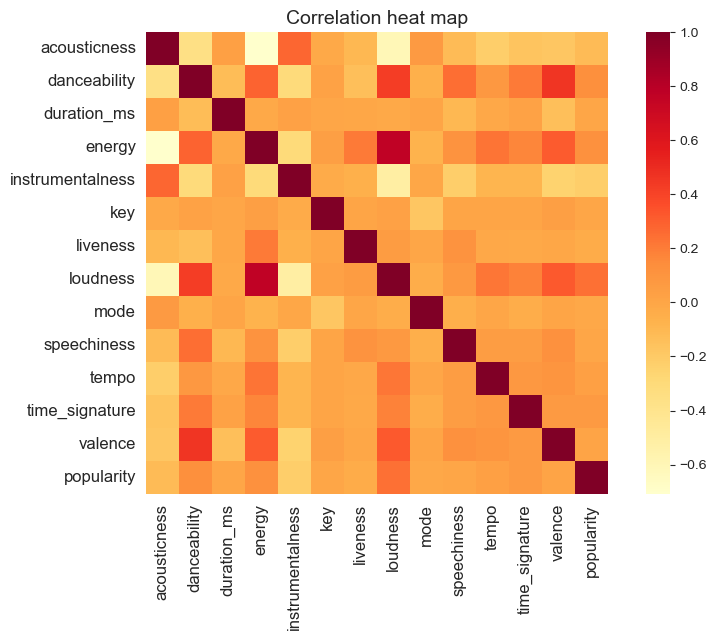

In [323]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
_ = sns.heatmap(spotify.corr(numeric_only=True), square=True, cmap='YlOrRd')
_ = plt.title('Correlation heat map', fontsize=14)
_ = plt.xticks(fontsize=12)
_ = plt.yticks(fontsize=12)

In general, the EDA shows that the data is heavily weighted towards unpopular songs and that there is a lot of noise and variability amongst the observations. 

The original row count was 111,774. Here we can verify the new shape.

In [326]:
print(spotify_ordered.shape)

(111774, 16)


### Linear Regression
With the example cases removed, the rest of the data is used here for training and testing a linear regression model using Scikit Learn. One important step is that the `spotify_ordered` dataset is shuffled to ensure that the song order does not introduce any bias, and the new shuffled data is stored as `reg_data`. For this initial test, to keep it as simple as possible, the categorical variables are omitted. 

In [328]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Set random state
state=25

# Shuffle the data
reg_data = spotify_ordered.sample(frac=1, random_state=state).reset_index(drop=True)

# First, try without categoricals
X = reg_data.select_dtypes(include='number').drop('popularity', axis=1)
y = reg_data.popularity

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=state)

Now that the data has been split with `train_test_split`, we can fit the training data and calculate the R<sup>2</sup> score. This process, and all the similar ones to follow, is timed to get an understanding of the computational requirements for each model.<br>
<br>
In addition to the standard R<sup>2</sup> score, I also created a custom loss function to give a more concrete perspective on the model performance. This function, `custom_loss`, calculates counts for different levels of error between the predicted values and the actual test values, and also gives an overall average of the differences between predicted and actual.

In [330]:
def custom_loss(prediction, actual):
    paired = zip(prediction, actual)
    listed = list(paired)
    diffs = {'Under five': 0, 'Five to ten': 0, 'Over ten': 0, 'Average error': 0}
    sum = 0

    for pair in listed:
        sum += abs(pair[0] - pair[1])
        if abs(pair[0] - pair[1]) < 5:
            diffs['Under five'] += 1
        elif 5 <= abs(pair[0] - pair[1]) < 10:
            diffs['Five to ten'] += 1
        else:
            diffs['Over ten'] += 1
            
    diffs['Average error'] = sum / len(listed)
     
    return diffs

With the custom loss function set and the data split, we can begin running the models.

In [332]:
%%time

linreg = LinearRegression()
linreg.fit(X_train, y_train)

lin_pred = linreg.predict(X_test)

print(linreg.score(X_test, y_test))

0.09837878124451915
CPU times: user 410 ms, sys: 74.1 ms, total: 484 ms
Wall time: 98.7 ms


In [333]:
custom_loss(lin_pred, y_test)

{'Under five': 5861,
 'Five to ten': 5472,
 'Over ten': 16611,
 'Average error': 14.206848540557287}

The score for the model above is not very good. On the other hand, the custom metric isn't as bad as the score would lead one to believe. There may be over 16,000 predictions well off the mark, but a good many were reasonably accurate, and the average difference isn't terrible.<br>
<br>
To take it a step further, let's see what happens when using the categoricals by using one hot encoding with `.get_dummies()`. For this step, I decided to drop the `artist_name` column. While song popularity is often correlated with artist popularity, the hope is for this model to work just as well on an artist it hasn't seen before. Part of the goal is to be able to discover new talent, and that becomes more difficult if the algorithm is inclined to discredit a song just because it doesn't recognize the artist. Therefore, the column is dropped for training purposes. This new dataset is stored as `df_encoded`.

In [335]:
no_artist = reg_data.drop(['artist_name', 'track_name'], axis=1)
df_encoded = pd.get_dummies(no_artist)
df_encoded.columns

Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'popularity', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4',
       'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11',
       'mode_0', 'mode_1', 'time_signature_0', 'time_signature_1',
       'time_signature_3', 'time_signature_4', 'time_signature_5'],
      dtype='object')

We can see above that the category variables have been separated into unique columns for each respective value. With the new data, new train and test splits need to be created, and the model re-run.

In [337]:
XX = df_encoded.drop('popularity', axis=1)
yy = df_encoded.popularity

X_train, X_test, y_train, y_test = train_test_split(XX, yy, test_size=0.25, random_state=state)

Now fit and check the score:

In [339]:
%%time
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(lr.score(X_test, y_test))

0.09995186109791099
CPU times: user 476 ms, sys: 221 ms, total: 697 ms
Wall time: 142 ms


And now the custom score:

In [341]:
custom_loss(lr_pred, y_test)

{'Under five': 5913,
 'Five to ten': 5438,
 'Over ten': 16593,
 'Average error': 14.196137502488497}

The result is better, but only marginally. To help ensure this result is accurate, cross-validation can be used.

In [343]:
from sklearn.model_selection import cross_val_score

# Use the regressor from above to set up the cross_val
cvals = cross_val_score(lr, XX, yy, cv=6)

# check the results
print(cvals)
print('The mean cross-validatoin score is: {num:.{dig}f}'.format\
      (num=np.mean(cvals), dig=4))

[0.10283964 0.1004429  0.09977221 0.094989   0.1048918  0.09949721]
The mean cross-validatoin score is: 0.1004


The results are fairly similar across all of the folds, and the mean score is about the same as all of the previous results.

This seems to indicate that plain linear regression isn't well suited for this problem, which isn't surprising. To improve on it, I tried using ridge regression next.

#### Ridge regression
In an attempt to improve the results from the basic linear regression model, we can use ridge regression. 

In [346]:
%%time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge = make_pipeline(StandardScaler(), Ridge(alpha=0.5))
ridge.fit(X_train, y_train)

print(ridge.score(X_test, y_test))

0.09995187128635463
CPU times: user 414 ms, sys: 61.9 ms, total: 476 ms
Wall time: 117 ms


In [347]:
custom_loss(ridge.predict(X_test), y_test)

{'Under five': 5913,
 'Five to ten': 5438,
 'Over ten': 16593,
 'Average error': 14.196138438719842}

This first attempt is worse than basic linear regression, but we can try to improve the result with grid-search cross validation.

In [349]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

alphas = {'ridge__alpha': [0.0005, 0.0006, 0.00075, 0.0009, 0.001]}

# include both scaler and Ridge model in pipeline
rg = make_pipeline(StandardScaler(), Ridge())

rg_cv = GridSearchCV(rg, alphas, cv=6)
rg_cv.fit(XX, yy)

print(rg_cv.best_params_)
print(rg_cv.best_score_)

{'ridge__alpha': 0.001}
0.1004054594317204


The ridge model improved, but it's still more or less the same os basic regression.

<b>Plotting actual versus predicted values</b><br>
The plot below might give a clue as to why the linear models are performing so poorly. The range of predicted values is much narrower than the actual popularity values. This makes sense when thinking about linear regressions and recalling the plots from the data story report: The prediction is a single line through a cloud of observations. This is similar to what is seen in the plot below.

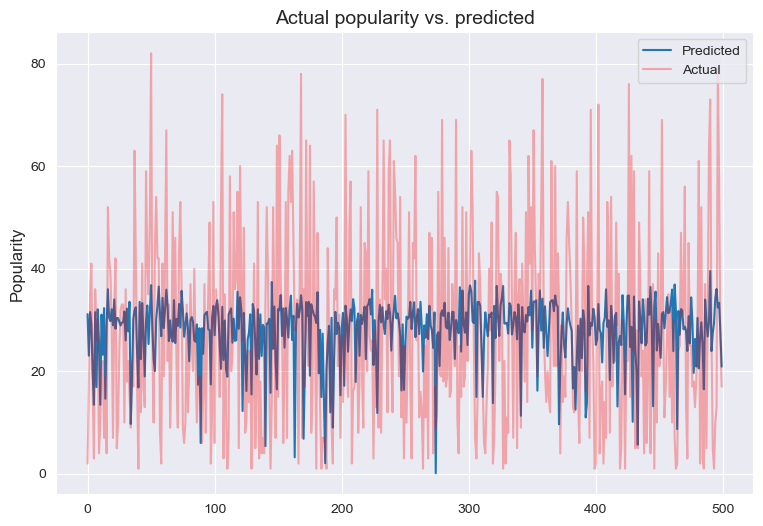

In [352]:
fig = plt.subplots(figsize=(9,6))
_ = plt.plot(list(rg_cv.predict(X_test))[:500], label='Predicted')
_ = plt.plot(list(y_test)[:500], c='r', alpha=0.3, label='Actual')
_ = plt.legend(loc='upper right')
_ = plt.ylabel('Popularity', fontsize=12)
_ = plt.title('Actual popularity vs. predicted', fontsize=14)

### Classification
Because the regression models are not getting the job done, the next step is to use the `classified` dataset and try a classification approach.

<b>Class counts</b><br>
The different classes in the classified dataset exhibit a high level of imbalance. This needs to be accounted for in order to ensure the models perform as well as possible. Here's a visualization of the disparity.

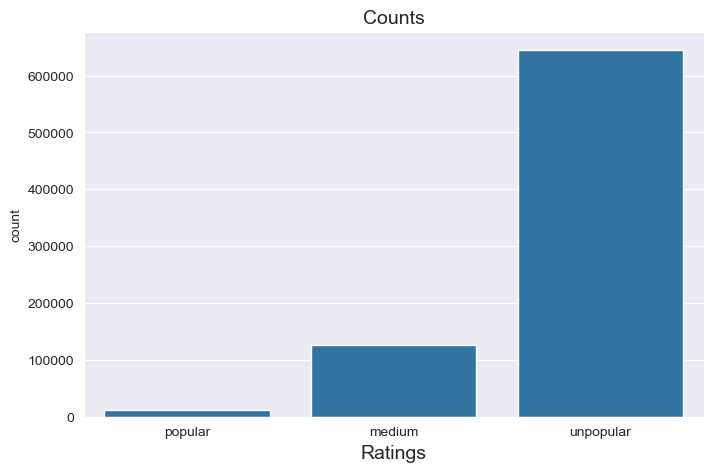

In [355]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
_ = sns.countplot(x='pop_rating', data=classified)
_ = plt.xlabel('Ratings', fontsize=14)
_ = plt.title('Counts', fontsize=14)

##### Creating a balanced sample for the final test set
Instead of using a random sample for the final test set, here I manually create the test set in order to preserve the ratios of the labels.<br>
<br>
First, as before with the encoded dataframe from the regression model, I drop the `artist_name` column, along with `track_name`, and encode the categorical variables.

In [357]:
df = classified.drop(['artist_name', 'track_name'], axis=1)
df = pd.get_dummies(df, columns=['key', 'mode', 'time_signature'])
df.shape

(781634, 32)

Next, I create a separate dataframe with all the observations for each label, and then split each of those into train and test splits. All of the training splits and then all of the test splits are then stitched together so that all labels are represented in the data. Importantly, the popularity column is dropped completely to ensure that it is not included as a training feature.

In [359]:
from sklearn.model_selection import train_test_split

df_pop = df[df.pop_rating == 'popular']

df_med = df[df.pop_rating == 'medium']

df_unpop = df[df.pop_rating == 'unpopular']

# Set random seed
state=25

X_tr_p, X_ts_p, y_tr_p, y_ts_p = train_test_split(df_pop.drop(['popularity', 'pop_rating'], axis=1),\
                                                 df_pop.pop_rating, test_size=0.15, random_state=state)

X_tr_m, X_ts_m, y_tr_m, y_ts_m = train_test_split(df_med.drop(['popularity', 'pop_rating'], axis=1),\
                                                 df_med.pop_rating, test_size=0.15, random_state=state)

X_tr_up, X_ts_up, y_tr_up, y_ts_up = train_test_split(df_unpop.drop(['popularity', 'pop_rating'], axis=1),\
                                                 df_unpop.pop_rating, test_size=0.15, random_state=state)

Here the training splits are merged to form one training set, stored as `training`, and then reshuffled to randomize the data. The output shows the shape of the training set.

In [361]:
pop_train = pd.concat([X_tr_p, y_tr_p], axis=1)
med_train = pd.concat([X_tr_m, y_tr_m], axis=1)
unpop_train = pd.concat([X_tr_up, y_tr_up], axis=1)

training = pd.concat([pop_train, med_train, unpop_train], axis=0)

training = training.sample(frac=1, random_state=state).reset_index(drop=True)

# Popularity has been removed, so only 30 columns
training.shape

(664388, 31)

The same process above is now executed with the final test data.

In [363]:
pop_test = pd.concat([X_ts_p, y_ts_p], axis=1)
med_test = pd.concat([X_ts_m, y_ts_m], axis=1)
unpop_test = pd.concat([X_ts_up, y_ts_up], axis=1)

final_test = pd.concat([pop_test, med_test, unpop_test], axis=0)

final_test = final_test.sample(frac=1, random_state=state).reset_index(drop=True)

final_test.shape

(117246, 31)

Now we have a training set of about 95,000 observations, stored as `training`, and a test set of about 16,800 rows, stored as `final_test`. With the data split, we can now train the models using the training data.

<b> Train and validation sets</b><br>
Before actually diving into the models, the training data needs to be further split into training and validation sets to allow testing without using the final test set.

In [366]:
X_class = training.drop('pop_rating', axis=1)
y_class = training.pop_rating

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.25, random_state=state)

#### Decision Tree
To start off simple, I first ran a basic decision tree classifier. This only generates one tree so it's not computationally intensive, but it's also susceptible to overfitting.

In [368]:
%%time

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Basic decision tree
dt = DecisionTreeClassifier(max_depth=20, random_state=state)
dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print(accuracy_score(pred, y_test))

0.9609625700644804
CPU times: user 6.17 s, sys: 75.3 ms, total: 6.24 s
Wall time: 6.26 s


#### Random Forest
Taking the tree models a step further, I next ran Random Forest.

In [388]:
%%time

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=state)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(accuracy_score(rf_pred, y_test))

0.9830460514036978
CPU times: user 1min 24s, sys: 1.18 s, total: 1min 25s
Wall time: 1min 26s


Below is a chart ranking the features in level of importance for the random forests model.

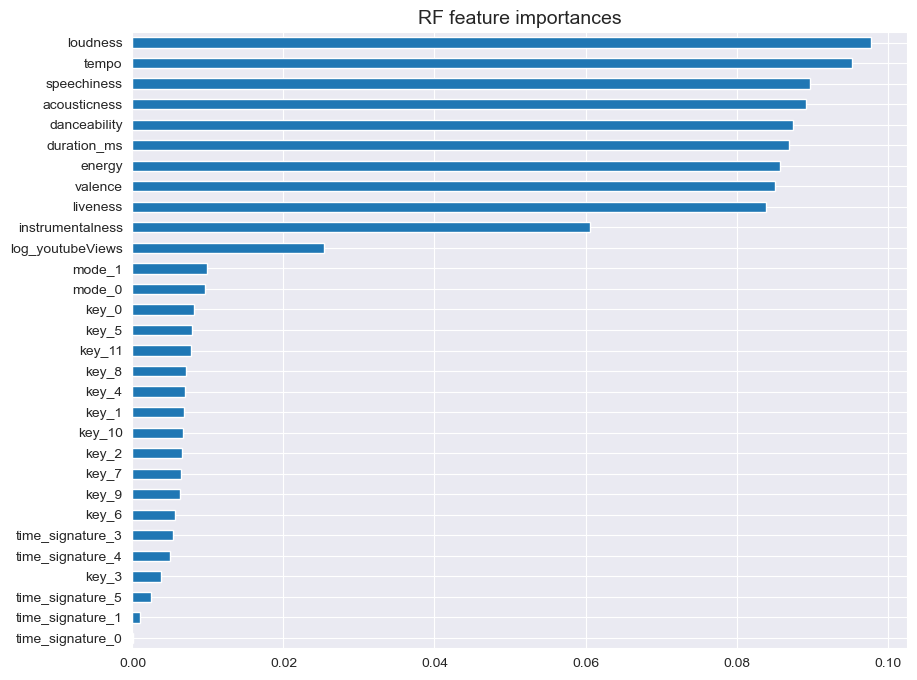

In [372]:
important = pd.Series(data=rf.feature_importances_, index=X_train.columns).sort_values()

fig = plt.subplots(figsize=(10,8))
_ = important.plot(kind='barh')
_ = plt.title('RF feature importances', fontsize=14)

##### Random forest

In [374]:
confusion_matrix(y_test, rf_pred)

array([[ 24056,      0,   2646],
       [     1,   2234,    157],
       [    11,      1, 136991]])

In [375]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rfb_p, labels=np.unique(y_test)))


              precision    recall  f1-score   support

      medium       1.00      0.90      0.95     26702
     popular       1.00      0.93      0.97      2392
   unpopular       0.98      1.00      0.99    137003

    accuracy                           0.98    166097
   macro avg       0.99      0.94      0.97    166097
weighted avg       0.98      0.98      0.98    166097



In [376]:
X_train.columns

Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'log_youtubeViews', 'key_0', 'key_1', 'key_2', 'key_3',
       'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10',
       'key_11', 'mode_0', 'mode_1', 'time_signature_0', 'time_signature_1',
       'time_signature_3', 'time_signature_4', 'time_signature_5'],
      dtype='object')

Now with random forests:

In [378]:
rf_ho_p = rf_b.predict(X_final)

print(accuracy_score(rf_ho_p, y_final))

0.9825580403595858


In [379]:
confusion_matrix(y_final, rf_ho_p)

array([[16917,     1,  1916],
       [    0,  1572,   115],
       [   11,     2, 96712]])

In [380]:
print(classification_report(y_final, rf_ho_p, labels=np.unique(y_final)))

              precision    recall  f1-score   support

      medium       1.00      0.90      0.95     18834
     popular       1.00      0.93      0.96      1687
   unpopular       0.98      1.00      0.99     96725

    accuracy                           0.98    117246
   macro avg       0.99      0.94      0.97    117246
weighted avg       0.98      0.98      0.98    117246



## Conclusions

To recap, here is an overview of the performance of all the models ran on purely audio features.

#### Linear Regression Results
| Algorithm                             | Score  | Custom Loss Average | Execution Time |
|---------------------------------------|--------|---------------------|----------------|
| Linear Regression - No categoricals   | 0.0979 | 14.24               | 78.1 ms        |
| Linear Regression - With categoricals | 0.0994 | 14.22               | 93.4 ms        |
| Ridge Regression                      | 0.1004 | 14.34               | 67.6 ms        |

#### Classification Results
| Algorithm          | Validation Set Score | Validation Set Popular Recall | Hold Out Popular Recall | Execution Time |
|-------------------|----------------------|-------------------------------|-------------------------|----------------|
| Decision Tree     | 0.8585               | 0                             | --                      | 1.03 s         |
| Bagging           | 0.8571               | 0.67                          | 0.76                    | 18.6 s         |
| Random Forest     | 0.8608               | 0.02                          | 0.03                    | 40.1 s         |
| Gradient Boosting | 0.8582               | --                            | --                      | 1 min 48 s     |
| AdaBoost          | 0.8584               | 0.39                          | 0.46                    | 1 min 5 s      |

In [386]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)

loudness            0.097754
tempo               0.095310
speechiness         0.089717
acousticness        0.089171
danceability        0.087478
duration_ms         0.086895
energy              0.085738
valence             0.085052
liveness            0.083901
instrumentalness    0.060551
dtype: float64